## Xenium BRCA — StarDist prediction visualization

Twin of `CODEX_hcc/Pred_statistic_visual_hcc_all.ipynb` / `Xenium_lung/Pred_statistic_visual_xenium_all.ipynb`.

The 10x breast preview has **no clinical groups**. This notebook:

1. Plots **pooled StarDist ROC** for L2 / L12 / L1 on `rep1` + `rep2`.
2. Compares **per-replicate macro AUROC**.

Requires cross-dataset outputs under `data/Xemium/BRCA/Results/result_all_spatial/stardist/`.

```bash
python -u code/Xenium_brca/BRCA_train_validate_cv_UNIlabel.py \
  --mode cross-dataset --use-spatial-context --spatial-k 8 --spatial-mode mean \
  --pooled-save-result result_all_spatial
```


In [1]:
import matplotlib
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

import sys
import warnings
import logging
from pathlib import Path

warnings.filterwarnings("ignore")
logging.getLogger("ome_zarr").setLevel(logging.ERROR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO = Path("/home/lingyu/ssd2/Python/Hist2Pheno")
for _p in (REPO / "code" / "Hist2Pheno_pkg", REPO / "code" / "Xenium_brca"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

PAN_ORGAN = "xenium_brca"
BRCA_ROOT = REPO / "data" / "Xemium" / "BRCA"
DATA_ROOT = BRCA_ROOT / "Results"
STARDIST_RESULT_ROOT = DATA_ROOT / "result_all_spatial" / "stardist"
OUT_DIR = DATA_ROOT / "result_all_spatial" / "pred_viz"
OUT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLES = ["rep1", "rep2"]
TIERS = ("l2", "l12", "l1")

print("DATA_ROOT:", DATA_ROOT)
print("STARDIST :", STARDIST_RESULT_ROOT)
print("OUT_DIR  :", OUT_DIR)
print("exists   :", STARDIST_RESULT_ROOT.is_dir())


DATA_ROOT: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results
STARDIST : /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/stardist
OUT_DIR  : /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/pred_viz
exists   : True


## Pooled StarDist ROC (rep1 + rep2)

Uses `uni_label_cv_helpers.plot_pooled_stardist_tier_rocs` on the cross-dataset StarDist folders.


Linked 2/2 StarDist sample dirs under /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/pred_viz/_tmp_selected_stardist

=== L2 | discovering validation_external_stardist_matched_AUROC.csv ===
  rep1: 146,878 cells, 16 local classes
  rep2: 98,140 cells, 16 local classes
Saved pooled AUROC concat: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/pred_viz/validation_external_stardist_matched_AUROC_all_samples_concat.csv (245,018 rows)
Saved global class names: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/pred_viz/validation_external_stardist_matched_AUROC_all_samples_class_names.csv (16 classes)
Pooled: 245,018 cells from 2 samples; 16 global final_CT classes
  ROC colors: xenium_brca_fine (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/pred_viz/roc_stardist_l2_cross_dataset_all_Complete_Cases_pooled

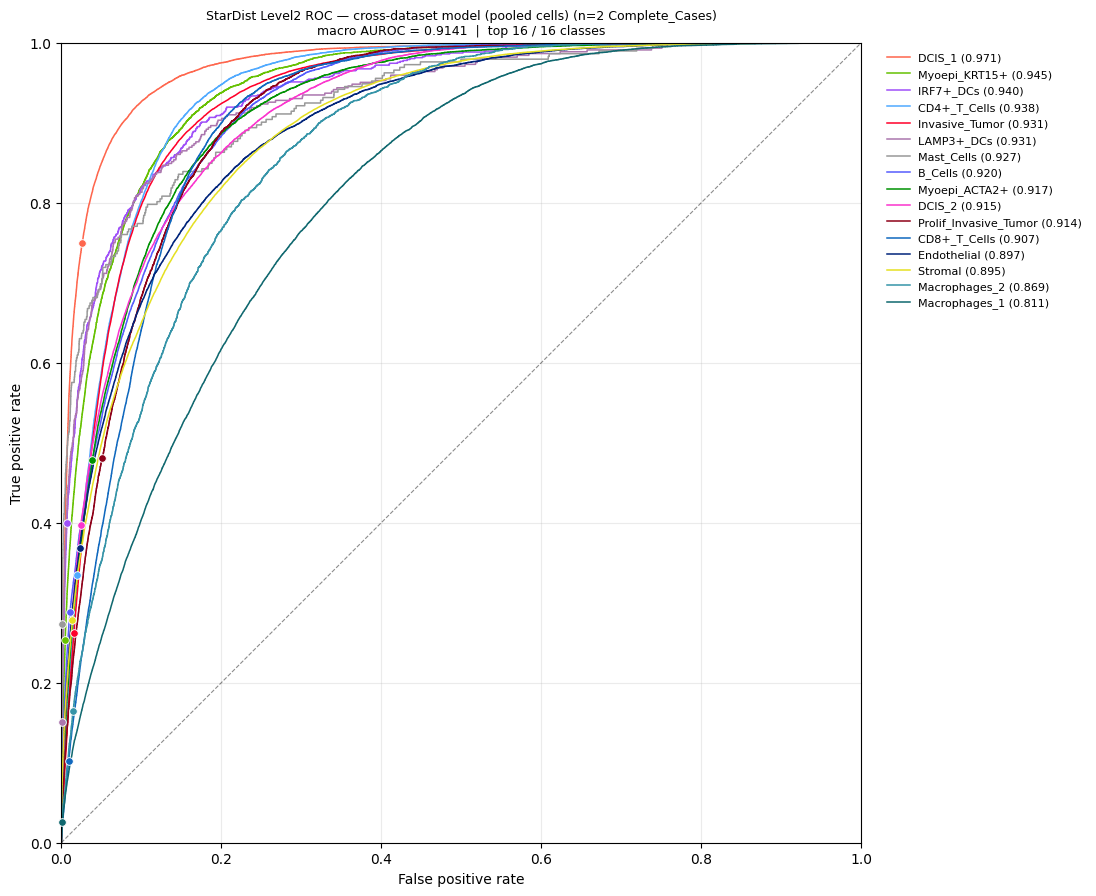

Pooled macro AUROC (L2): 0.9141

=== L12 | discovering validation_external_stardist_matched_AUROC_level12.csv ===
  rep1: 146,878 cells, 8 local classes
  rep2: 98,140 cells, 8 local classes
Saved pooled AUROC concat: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/pred_viz/validation_external_stardist_matched_AUROC_level12_all_samples_concat.csv (245,018 rows)
Saved global class names: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/pred_viz/validation_external_stardist_matched_AUROC_level12_all_samples_class_names.csv (8 classes)
Pooled: 245,018 cells from 2 samples; 8 global final_sublineage classes
  ROC colors: xenium_brca_intermediate (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/pred_viz/roc_stardist_l12_cross_dataset_all_Complete_Cases_pooled.pdf


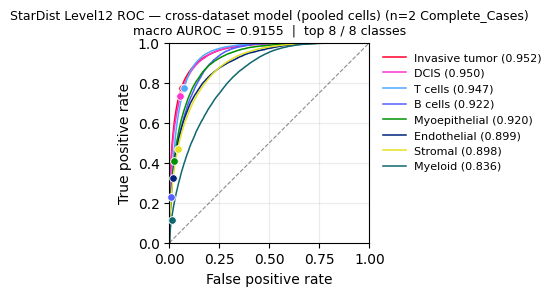

Pooled macro AUROC (L12): 0.9155

=== L1 | discovering validation_external_stardist_matched_AUROC_level1.csv ===
  rep1: 146,878 cells, 4 local classes
  rep2: 98,140 cells, 4 local classes
Saved pooled AUROC concat: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/pred_viz/validation_external_stardist_matched_AUROC_level1_all_samples_concat.csv (245,018 rows)
Saved global class names: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/pred_viz/validation_external_stardist_matched_AUROC_level1_all_samples_class_names.csv (4 classes)
Pooled: 245,018 cells from 2 samples; 4 global final_lineage classes
  ROC colors: xenium_brca_coarse (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/pred_viz/roc_stardist_l1_cross_dataset_all_Complete_Cases_pooled.pdf


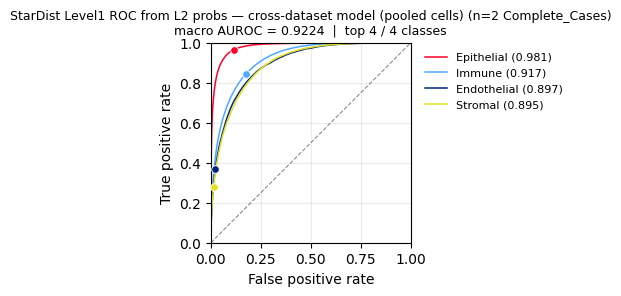

Pooled macro AUROC (L1): 0.9224
Wrote pooled ROC for: ['l2', 'l12', 'l1']


In [2]:
import importlib
import uni_label_cv_helpers as uni_nb

importlib.reload(uni_nb)
from uni_label_cv_helpers import (
    plot_pooled_stardist_tier_rocs,
    symlink_stardist_sample_dirs,
    build_stardist_sample_macro_auroc_table,
)

filtered_root = symlink_stardist_sample_dirs(
    STARDIST_RESULT_ROOT,
    SAMPLES,
    OUT_DIR / "_tmp_selected_stardist",
)

pooled_roc = plot_pooled_stardist_tier_rocs(
    filtered_root,
    OUT_DIR,
    TIERS,
    layout="pooled_stardist",
    pan_organ=PAN_ORGAN,
    figsize={"l12": (2.0, 2.0), "l1": (2.0, 2.0)},
)
print("Wrote pooled ROC for:", list(pooled_roc))


## Per-replicate macro AUROC

One row per sample (`rep1`, `rep2`) and three-head columns `macro_auc_l2` / `macro_auc_l12` / `macro_auc_l1`.


,Sample,macro_auc_l2,macro_auc_l12,macro_auc_l1
0,rep1,0.914791,0.914421,0.921726
1,rep2,0.912916,0.916708,0.923263


Wrote /home/lingyu/ssd2/Python/Hist2Pheno/data/Xemium/BRCA/Results/result_all_spatial/pred_viz/stardist_macro_auroc_by_replicate.csv


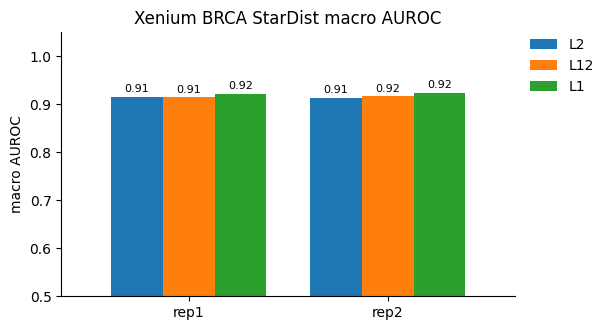

In [3]:
auroc_tbl = build_stardist_sample_macro_auroc_table(
    filtered_root,
    tiers=TIERS,
    layout="pooled_stardist",
)
out_csv = OUT_DIR / "stardist_macro_auroc_by_replicate.csv"
if len(auroc_tbl):
    auroc_tbl.to_csv(out_csv, index=False)
    display(auroc_tbl)
    print("Wrote", out_csv)

    plot_df = auroc_tbl.set_index("Sample")
    cols = [c for c in plot_df.columns if c.startswith("macro_auc_")]
    # Shorter legend labels: macro_auc_l2 → L2, etc.
    rename = {c: c.replace("macro_auc_", "").upper() for c in cols}
    ax = plot_df[cols].rename(columns=rename).plot(
        kind="bar", figsize=(6.2, 3.4), rot=0, width=0.78
    )
    ax.set_ylabel("macro AUROC")
    ax.set_xlabel("")
    ax.set_ylim(0.5, 1.05)
    ax.set_title("Xenium BRCA StarDist macro AUROC")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", padding=2, fontsize=8)
    ax.legend(
        title=None,
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0.0,
    )
    fig = ax.get_figure()
    fig.tight_layout()
    fig.savefig(
        OUT_DIR / "stardist_macro_auroc_by_replicate.pdf",
        bbox_inches="tight",
    )
    plt.show()
else:
    print("No AUROC CSVs yet. Run the cross-dataset CLI / all notebook first.")


## Notes

- BRCA has no Response / diagnosis / treatment metadata, so this notebook does not run HCC clinical tests.
- Spatial prediction maps are written per replicate under `Results/result_all_spatial/stardist/{rep1,rep2}/`.
- Palettes: `PAN_ORGAN="xenium_brca"` (Janesick / LY hierarchy colors).
